# Crime Trends Analysis in South Africa

## Project Goal
This project analyzes crime statistics in South Africa to identify patterns, trends, and high-risk provinces.


## Key Questions

1. Which provinces have the highest crime rates?
2. Which crime categories are most common?
3. Are certain crimes increasing or decreasing over time?
4. What patterns can be observed?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [3]:
"""
    Extracts the raw CSV data and returns a pandas DataFrame.
    
    Parameters:
    file_path (str): Path to the CSV file.
    
    Returns:
    pd.DataFrame: Raw data from the CSV.
"""


def extract(csv_file ='../data/SouthAfricaCrimeStats_v2.csv' ):

    df = pd.read_csv(csv_file)
    return df

df = extract()
df.head()


,Province,Station,Category,2005-2006,2006-2007,2007-2008,2008-2009,2009-2010,2010-2011,2011-2012,2012-2013,2013-2014,2014-2015,2015-2016
0,Western Cape,Cape Town Central,All theft not mentioned elsewhere,6692,6341,5966,5187,4985,5127,5285,5937,5600,5335,5176
1,Gauteng,Jhb Central,All theft not mentioned elsewhere,6093,4602,3761,3610,3267,3037,2886,2638,2809,3050,2434
2,Western Cape,Mitchells Plain,All theft not mentioned elsewhere,5341,6093,6316,6803,6035,5761,6108,5514,4975,4043,3635
3,Free State,Park Road,All theft not mentioned elsewhere,5108,4282,3834,3316,3101,3013,2679,3116,2927,2297,2103
4,Gauteng,Pretoria Central,All theft not mentioned elsewhere,5099,4536,3309,2694,2616,2606,2635,3226,3246,2892,3030


In [5]:
# TRANSFORM
raw_data = extract()
def transform(df):
    """
    Clean and transform the raw dataframe.
    """
    # 1. Make a copy (good practice)
    df_clean = df.copy()

    # 2. Standardize column names
    df_clean.columns = df_clean.columns.str.strip().str.lower()
   

    # 3. Handle missing values (placeholder for now)
    df_clean = df_clean.dropna()


    #melted columns from wide to long , placed years and the values in separate columns
    df_long = df_clean.melt(
        id_vars=["province","station","category"],
        var_name="year",
        value_name="cases"
    )
    df_long["year"] = df_long["year"].str[:4].astype(int)
     

    return df_long

df = transform(raw_data)
df.head()


,province,station,category,year,cases
0,Western Cape,Cape Town Central,All theft not mentioned elsewhere,2005,6692
1,Gauteng,Jhb Central,All theft not mentioned elsewhere,2005,6093
2,Western Cape,Mitchells Plain,All theft not mentioned elsewhere,2005,5341
3,Free State,Park Road,All theft not mentioned elsewhere,2005,5108
4,Gauteng,Pretoria Central,All theft not mentioned elsewhere,2005,5099


In [11]:
"""I want to load the data and store the cleaned data in a csv file """
def load(df, output_path="../data/cleaned_crime_data.csv"):
    df.to_csv(output_path, index=False)
    print(f"Transformed data saved to {output_path}")


In [12]:
"""Calling the entire pipeline"""

raw_df = extract()
df_transformed = transform(raw_df)
load(df_transformed)

Transformed data saved to ../data/cleaned_crime_data.csv


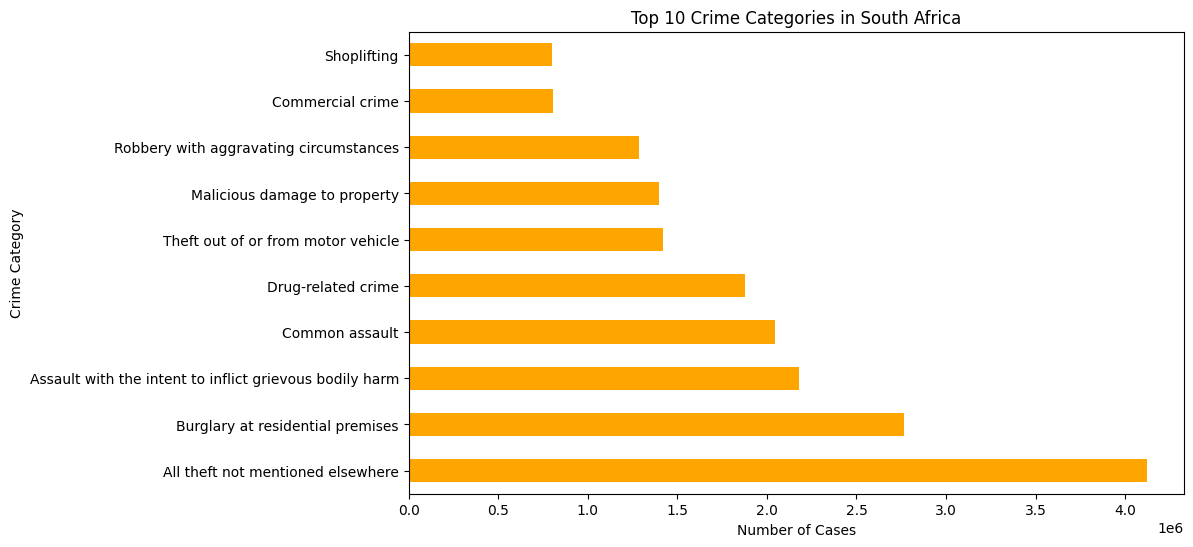

In [13]:
"""Plotting most common cases by category"""
category_totals = df_transformed.groupby("category")["cases"].sum().sort_values(ascending=False)

"""top 10 categories"""
top_10 = category_totals.head(10)

"""Plot"""
plt.figure(figsize=(10,6))  #width=10 , height= 6 
top_10.plot(kind="barh",color="orange")
plt.title("Top 10 Crime Categories in South Africa")
plt.xlabel("Number of Cases")
plt.ylabel("Crime Category")
plt.show()



/tmp/ipykernel_9888/3234466859.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


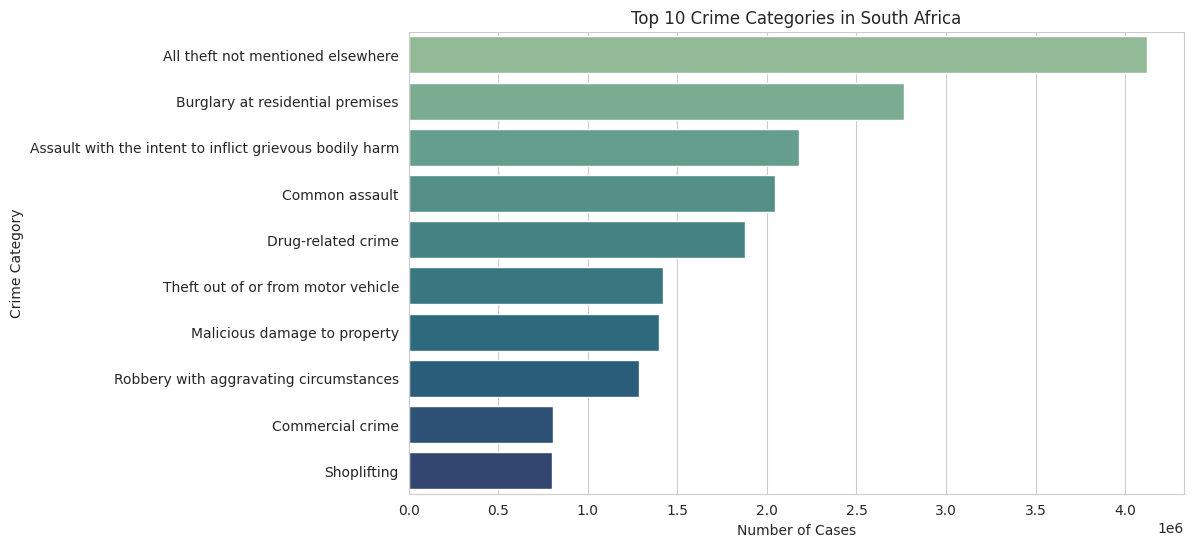

In [17]:
# Set a style
sns.set_style("whitegrid")

# Convert top_10 to DataFrame for Seaborn
top_10_df = top_10.reset_index()

plt.figure(figsize=(10,6))
sns.barplot(
    x="cases", 
    y="category", 
    data=top_10_df,
    palette="crest"  
)
plt.title("Top 10 Crime Categories in South Africa")
plt.xlabel("Number of Cases")
plt.ylabel("Crime Category")
plt.show() 

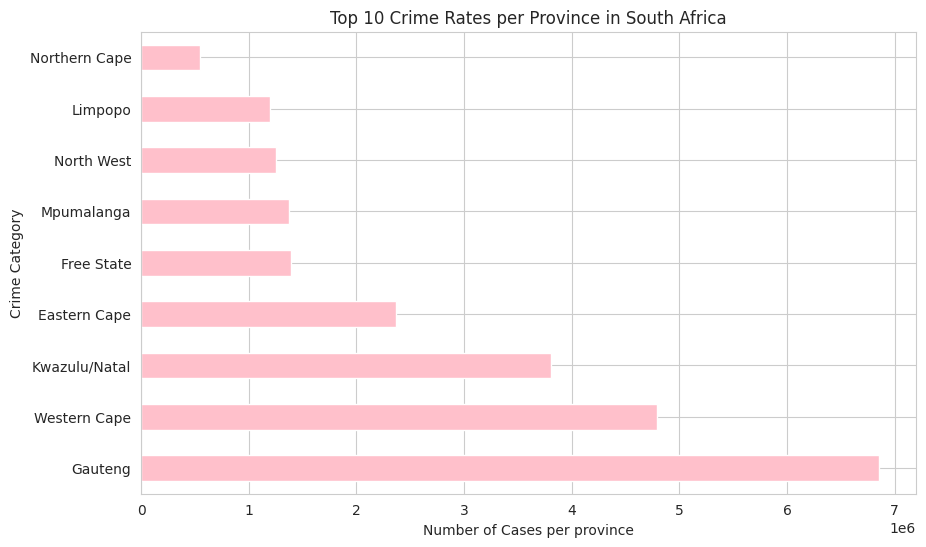

In [19]:
"""Plotting most common cases by category"""
province_totals = df_transformed.groupby("province")["cases"].sum().sort_values(ascending=False)

"""top 10 categories"""
top_10 = province_totals.head(10)

"""Plot"""
plt.figure(figsize=(10,6))  #width=10 , height= 6 
top_10.plot(kind="barh",color="pink")
plt.title("Top 10 Crime Rates per Province in South Africa")
plt.xlabel("Number of Cases per province")
plt.ylabel("Crime Category")
plt.show()

